In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_retail_data.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

C:\Users\vicky\AppData\Local\Temp\ipykernel_22864\3831162418.py:1: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Week,DayName
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,49,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,49,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,49,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,49,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,49,Tuesday


In [3]:
print("Shape :", df.shape)

print("\nColumns\n")

print(df.columns)

df.info()

Shape : (1007914, 14)

Columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Week', 'DayName'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1007914 entries, 0 to 1007913
Data columns (total 14 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1007914 non-null  object        
 1   StockCode    1007914 non-null  str           
 2   Description  1007914 non-null  str           
 3   Quantity     1007914 non-null  int64         
 4   InvoiceDate  1007914 non-null  datetime64[us]
 5   UnitPrice    1007914 non-null  float64       
 6   CustomerID   1007914 non-null  int64         
 7   Country      1007914 non-null  str           
 8   Revenue      1007914 non-null  float64       
 9   Year         1007914 non-null  int64         
 10  Month        1007914 non-null  int64         
 1

In [4]:
total_orders = df["InvoiceNo"].nunique()

total_products = df["StockCode"].nunique()

total_customers = df["CustomerID"].nunique()

total_quantity = df["Quantity"].sum()

total_revenue = df["Revenue"].sum()

print("Total Orders :", total_orders)

print("Total Products :", total_products)

print("Total Customers :", total_customers)

print("Total Quantity Sold :", total_quantity)

print("Total Revenue :", round(total_revenue,2))

Total Orders : 40081
Total Products : 4917
Total Customers : 5879
Total Quantity Sold : 11205149
Total Revenue : 20476634.02


In [5]:
yearly = df.groupby("Year")["Revenue"].sum().reset_index()

yearly

,Year,Revenue
0,2009,822483.950
1,2010,9833473.994
2,2011,9820676.074


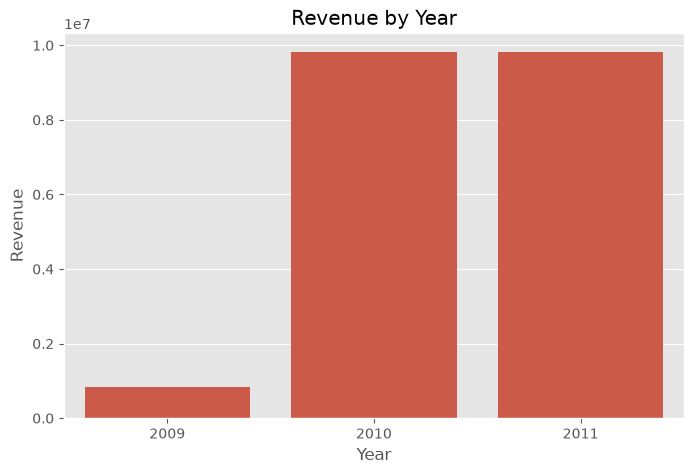

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=yearly,
    x="Year",
    y="Revenue"
)
plt.title("Revenue by Year")
plt.show()

In [7]:
monthly = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly

,Month,Revenue
0,1,1340966.722
1,2,1074423.856
2,3,1547130.521
3,4,1215843.743
4,5,1427002.110
5,6,1510084.320
6,7,1366886.391
7,8,1453093.290
8,9,1978132.183
9,10,2313165.950


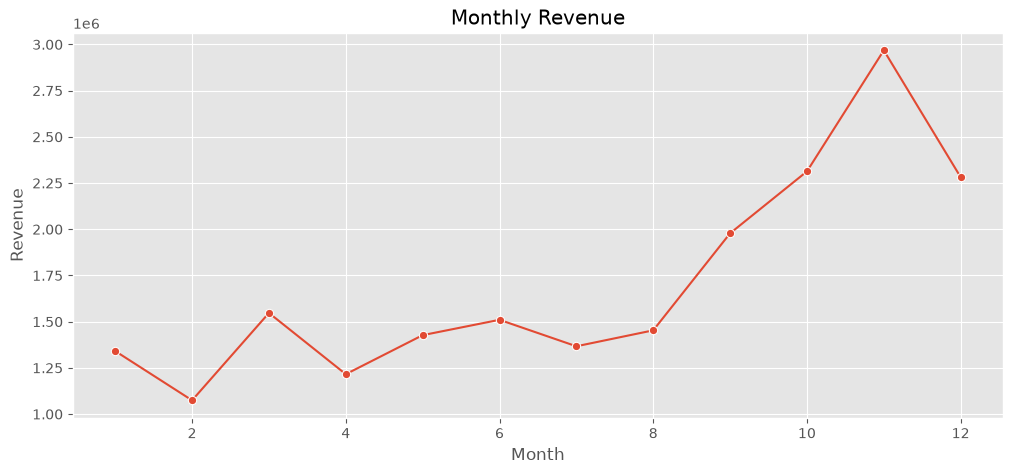

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly,
    x="Month",
    y="Revenue",
    marker="o"
)
plt.title("Monthly Revenue")
plt.show()

In [9]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
Manual                                339614.86
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64

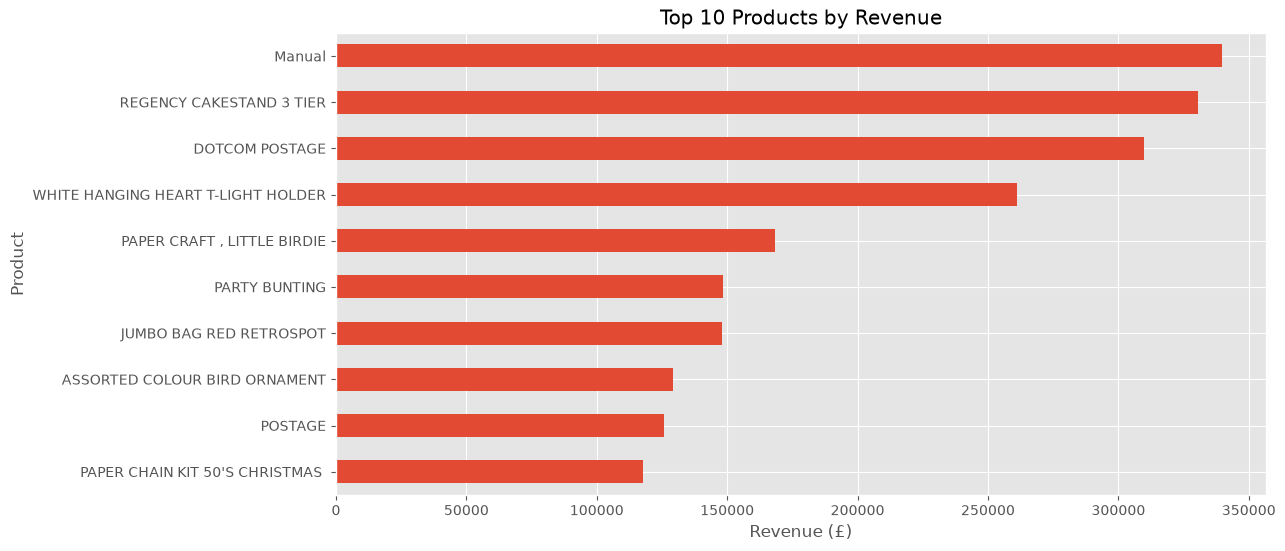

In [11]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.show()

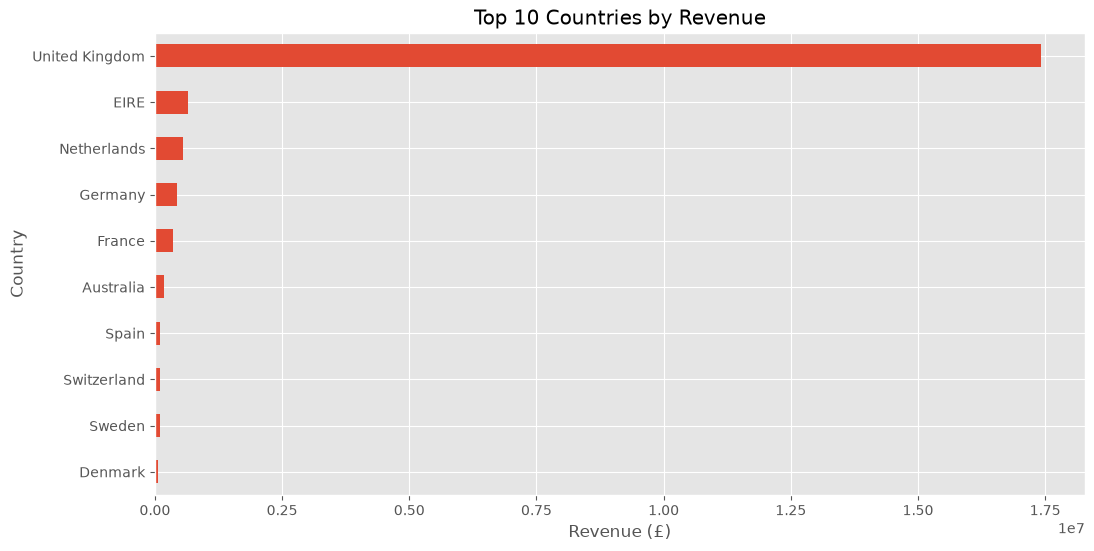

In [12]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.show()

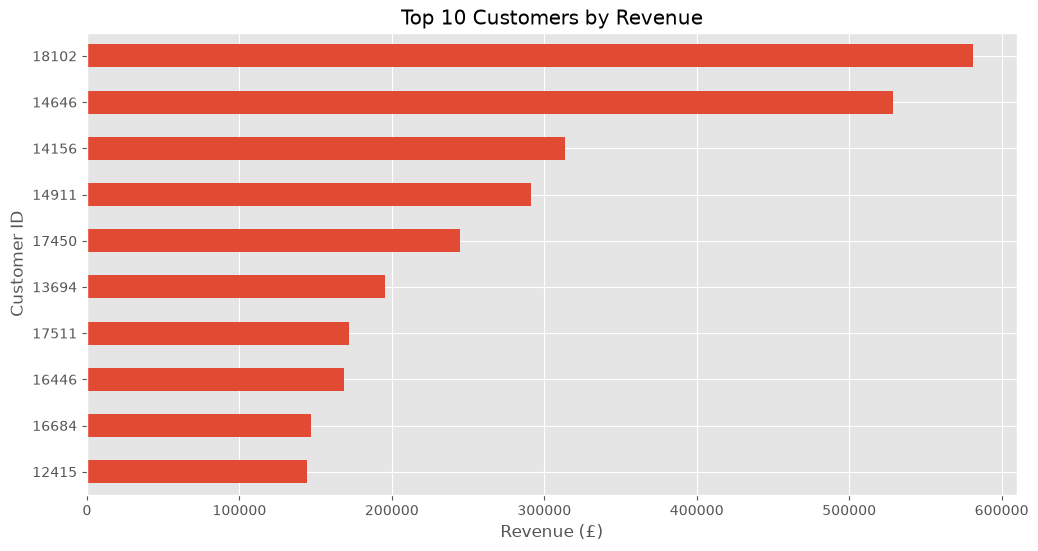

In [13]:
top_customers = (
    df[df["CustomerID"] != 0]
      .groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.show()

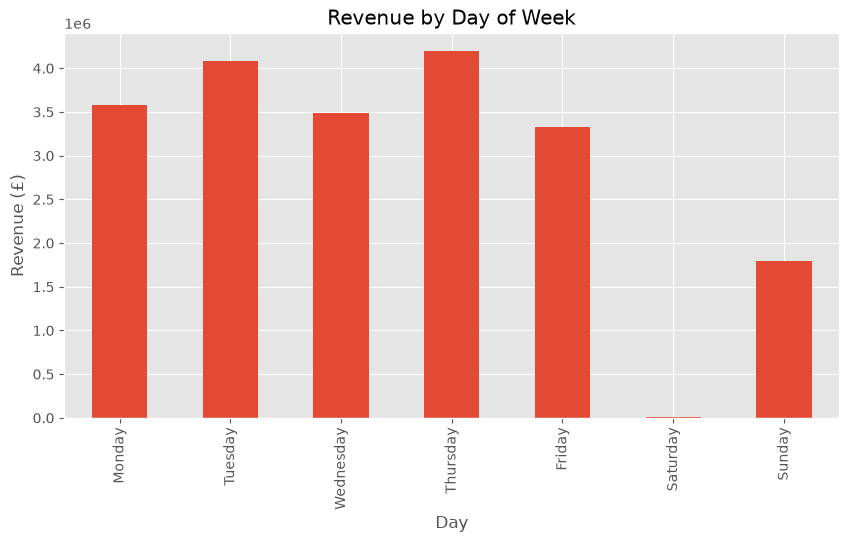

In [14]:
day_sales = (
    df.groupby("DayName")["Revenue"]
      .sum()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
)

plt.figure(figsize=(10,5))

day_sales.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.show()

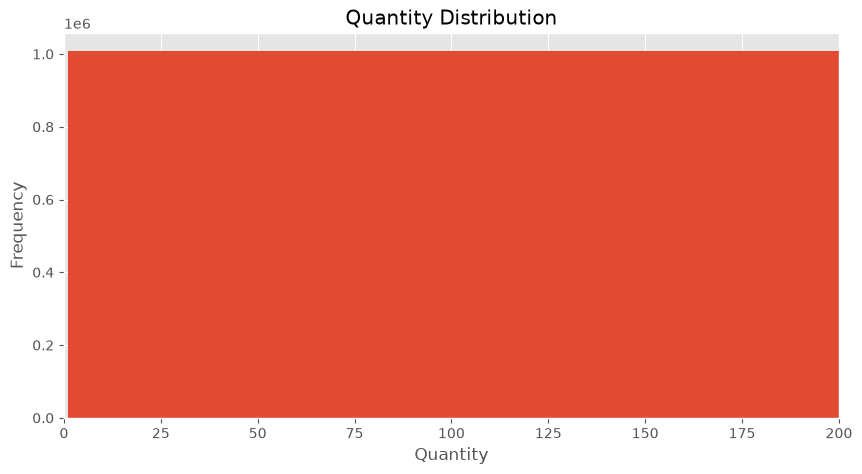

In [15]:
plt.figure(figsize=(10,5))

plt.hist(df["Quantity"], bins=50)

plt.xlim(0,200)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

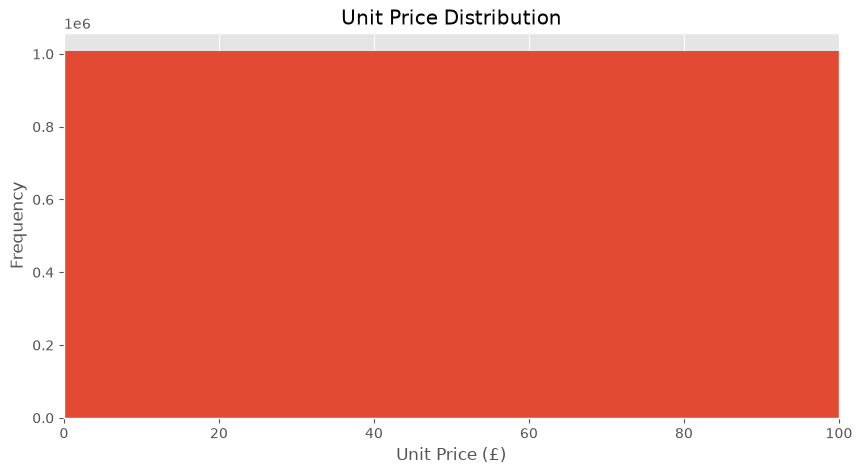

In [16]:
plt.figure(figsize=(10,5))

plt.hist(df["UnitPrice"], bins=50)

plt.xlim(0,100)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price (£)")
plt.ylabel("Frequency")

plt.show()